# Where you're born can cost you three decades of life

**Visual Medicine · One chart, one question.**

A single number — *life expectancy at birth* — quietly encodes centuries of history,
economics, and access to care. In 2023, that number ranges from the mid-50s to the
mid-80s depending on the country you happen to be born in.

This notebook loads the data, makes one honest editorial decision, and draws one chart.

*Data: [Our World in Data](https://ourworldindata.org/life-expectancy), life expectancy at birth, 2023.*

## 1. Load the data

The CSV lives next to this notebook (`life-expectancy.csv`) so the analysis is fully
reproducible offline. It was downloaded once from the source below:

```
https://ourworldindata.org/grapher/life-expectancy.csv
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Source: Our World in Data — life expectancy at birth.
# Downloaded from https://ourworldindata.org/grapher/life-expectancy.csv
df = pd.read_csv("life-expectancy.csv")
print(df.shape)
df.head()

(21565, 4)


,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975


## 2. Narrow to one year, and make one honest call

Two cleaning decisions, both worth stating out loud:

1. **Latest year only (2023).** We want a snapshot, not a time series.
2. **Drop aggregates and micro-states.** The file mixes real countries with regional
   aggregates ("World", "Africa") and tiny city-states (Monaco, San Marino). A three-decade
   gap between *Monaco and Chad* feels like a technicality; the same gap between *Japan and
   Chad* — two full-sized nations — is the real story. We keep recognizable countries so the
   comparison is honest, not a statistical curiosity.

In [2]:
# Latest snapshot
latest = df[df["Year"] == 2023].copy()

# World average, kept aside as a reference line
world_avg = df[(df["Entity"] == "World") & (df["Year"] == 2023)]["Life expectancy"].iloc[0]

# Real countries only (rows with a 3-letter ISO code, excluding the World aggregate)
countries = latest[
    latest["Code"].notna()
    & (latest["Code"].str.len() == 3)
    & (latest["Entity"] != "World")
]

print(f"World average (2023): {world_avg:.1f} years")
print(f"Highest: {countries.loc[countries['Life expectancy'].idxmax(), 'Entity']} "
      f"({countries['Life expectancy'].max():.1f})")
print(f"Lowest:  {countries.loc[countries['Life expectancy'].idxmin(), 'Entity']} "
      f"({countries['Life expectancy'].min():.1f})")

World average (2023): 73.2 years
Highest: Monaco (86.4)
Lowest:  Nigeria (54.5)


## 3. A curated spread

Rather than cram 200+ countries onto one axis, we pick a readable spread of ~15 —
the lowest few, a set of recognizable anchors (US, UK, China, India, Brazil), and the
highest large nations. The restraint *is* the point: a chart that makes one comparison
land beats a chart that shows everything and says nothing.

In [3]:
selection = [
    "Nigeria", "Chad", "South Sudan", "Central African Republic", "Lesotho",
    "India", "Ethiopia", "South Africa", "Brazil", "China",
    "United States", "United Kingdom", "South Korea", "Japan",
]

sub = (
    countries[countries["Entity"].isin(selection)]
    .loc[:, ["Entity", "Life expectancy"]]
    .sort_values("Life expectancy")
    .reset_index(drop=True)
)
sub

,Entity,Life expectancy
0,Nigeria,54.4623
1,Chad,55.0692
2,Lesotho,57.3749
3,Central African Republic,57.4077
4,South Sudan,57.6174
5,South Africa,66.1387
6,Ethiopia,67.3150
7,India,72.0026
8,Brazil,75.8482
9,China,77.9529


## 4. One chart

A Cleveland dot plot: sorted low → high, faint guide lines, the two extremes coloured, and
the world average as a reference. The title *is* the takeaway.

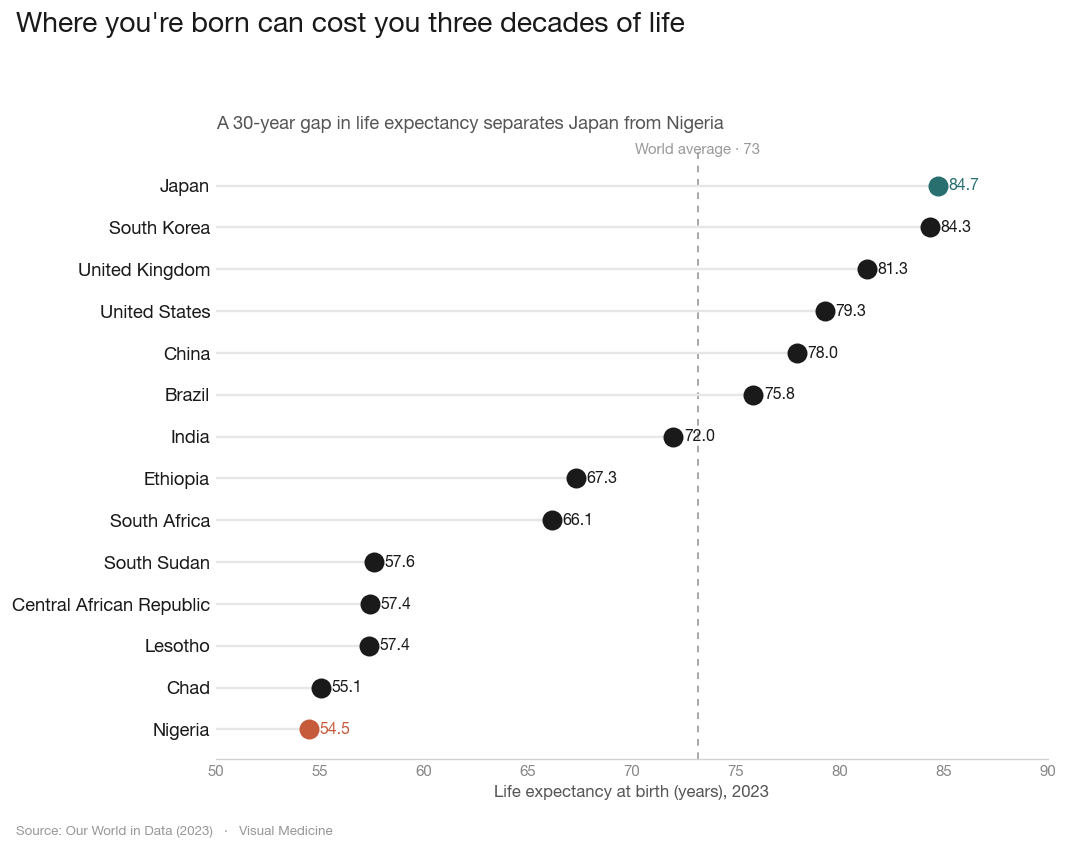

Gap between Japan and Nigeria: 30.2 years


In [4]:
# --- styling ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "figure.dpi": 120,
})

INK   = "#1a1a1a"   # neutral dots
GRAY  = "#9a9a9a"   # guide lines / muted
LOW   = "#c65b3c"   # lowest (warm)
HIGH  = "#2a6f6f"   # highest (deep teal)

labels = sub["Entity"].tolist()
values = sub["Life expectancy"].tolist()
y = range(len(labels))

lo_i, hi_i = 0, len(labels) - 1  # sorted, so first = lowest, last = highest

def dot_color(i):
    if i == lo_i: return LOW
    if i == hi_i: return HIGH
    return INK

fig, ax = plt.subplots(figsize=(9, 7))

# world-average reference line
ax.axvline(world_avg, color=GRAY, lw=1, ls=(0, (4, 4)), zorder=0)
ax.text(world_avg, len(labels) - 0.3, f"World average · {world_avg:.0f}",
        color=GRAY, fontsize=9, ha="center", va="bottom")

# guide lines + dots
for i, (lab, val) in enumerate(zip(labels, values)):
    c = dot_color(i)
    ax.hlines(i, 50, val, color="#e6e6e6", lw=1.4, zorder=1)
    ax.plot(val, i, "o", ms=11, color=c, zorder=2)
    # value label to the right of each dot
    ax.text(val + 0.5, i, f"{val:.1f}", va="center", ha="left",
            fontsize=9.5, color=c, fontweight="bold" if c != INK else "normal")

# country labels
ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=11, color=INK)

# axis cosmetics
ax.set_xlim(50, 90)
ax.set_ylim(-0.7, len(labels) - 0.2)
ax.set_xlabel("Life expectancy at birth (years), 2023", fontsize=10, color="#555")
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d0d0d0")
ax.tick_params(axis="x", colors="#888", length=0, labelsize=9)
ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)

# title = the takeaway
gap = values[hi_i] - values[lo_i]
fig.suptitle("Where you're born can cost you three decades of life",
             x=0.02, y=0.99, ha="left", fontsize=17, fontweight="bold", color=INK)
ax.set_title(
    f"A {gap:.0f}-year gap in life expectancy separates {labels[hi_i]} from {labels[lo_i]}",
    loc="left", fontsize=11, color="#555", pad=14)

# source
fig.text(0.02, 0.01, "Source: Our World in Data (2023)   ·   Visual Medicine",
         fontsize=8, color="#999", ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig("life-expectancy-gap.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()
print(f"Gap between {labels[hi_i]} and {labels[lo_i]}: {gap:.1f} years")

## What the chart hides

A national average is itself an aggregate. The same 30-year gap that separates countries
also opens *within* them — by income, postcode, and race. That's the next chart.

**One dataset. One decision. One story.**